<div style="color:white; background-color:#5b8c8c; padding:20px; border-radius:8px; font-size:26px">
<b><center>Motivation-Based Participant Segmentation</center></b>
</div>


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Project Overview**

</div>

This project applies unsupervised learning to explore motivation patterns across 49 participants.

Each participant is described by scores across 12 motivational categories, such as curiosity, appreciation, sense of community, order, movement, food, competition, and emotional calm. _Because there is no target variable, the goal is not to predict an outcome, but to discover structure in the data._

The project focuses on two main questions:

1. **Can participants be grouped according to similar motivation profiles?**
2. **Can motivation categories be grouped according to similar behavior across participants?**

The analysis uses clustering methods to explore these questions and compares the results from different approaches, including K-Means, hierarchical clustering, and DBSCAN.


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Why This Project Matters**

</div>

Motivation data can be useful when the goal is to understand behavioral patterns rather than predict a predefined label.

If meaningful participant groups exist, they may help describe different motivation profiles. If motivation categories cluster together, they may reveal related psychological or behavioral dimensions.

The value of this project is not only in assigning clusters, but in interpreting whether those clusters are stable, meaningful, and useful for understanding the structure of the data.


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Import Libraries and Set Up Paths**

</div>

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

PALETTE_MOTIVATION = {"cream": "#fbf8ef",
                      "grid": "#ffffff",
                      "gray": "#5f6368",
                      "dark_gray": "#3f4246",
                      "teal": "#8fcfd1",
                      "blue": "#9bc4e2",
                      "green": "#b8d8b8",
                      "pink": "#e8a7b8",
                      "coral": "#f2a7a0",
                      "mint": "#cfe8d5"
                     }

sns.set_theme(style="whitegrid")

plt.rcParams.update({"figure.facecolor": PALETTE_MOTIVATION["cream"],
                    "axes.facecolor": PALETTE_MOTIVATION["cream"],
                    "savefig.facecolor": PALETTE_MOTIVATION["cream"],
                    "axes.edgecolor": "#e6dfcf",
                    "axes.labelcolor": PALETTE_MOTIVATION["dark_gray"],
                    "xtick.color": PALETTE_MOTIVATION["gray"],
                    "ytick.color": PALETTE_MOTIVATION["gray"],
                    "text.color": PALETTE_MOTIVATION["dark_gray"],
                    "grid.color": PALETTE_MOTIVATION["grid"],
                    "grid.linewidth": 1.0,
                    "axes.titleweight": "regular",
                    "axes.titlesize": 14,
                    "axes.labelsize": 11,
                    "font.size": 11
                })

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import DBSCAN


In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


In [3]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
IMAGES_DIR = PROJECT_ROOT / "images"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_PATH = DATA_DIR / "Motivation_Challenge_Test.xlsx"

REPORTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)

Project root: D:\git\DS_team\Motivation_Challenge
Data path: D:\git\DS_team\Motivation_Challenge\data\Motivation_Challenge_Test.xlsx


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Data Description**

</div>


In [4]:
df = pd.read_excel(DATA_PATH)

display(df.head())

print("Dataset shape:", df.shape)


,Patient_ID,Power_and_influence,Sense_of_community,Curiosity,Appreciation,Collector,Sense_of_purpose,Food,Movement,Emotional_calm,Order,Eros_and_Beauty,Competition
0,P1,-0.428571,-0.285714,-0.428571,-0.428571,-0.285714,0.000000,-0.428571,-0.714286,0.000000,-0.428571,-0.285714,-0.285714
1,P2,0.285714,0.142857,1.000000,0.285714,0.571429,-0.428571,1.428571,-1.857143,1.142857,-0.428571,0.285714,-0.142857
2,P3,1.285714,0.571429,0.285714,0.714286,0.428571,0.428571,1.428571,0.571429,1.428571,1.000000,1.142857,0.714286
3,P4,1.428571,-0.142857,1.142857,0.428571,0.428571,0.000000,1.285714,-0.285714,1.428571,0.857143,1.000000,0.571429
4,P5,0.000000,0.000000,0.428571,0.714286,0.285714,0.285714,1.000000,-0.857143,1.285714,0.857143,0.142857,-0.142857


Dataset shape: (49, 13)


The dataset contains 49 participants and 13 columns.

- `Patient_ID` identifies each participant.
- The remaining 12 columns represent motivation scores across different motivational categories.
- The scores are numerical and approximately range from -2 to +2.



<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Initial Data Validation**

</div>

Before performing exploratory analysis or clustering, I check the basic structure and quality of the dataset.

This includes:

- column names and data types
- missing values
- duplicated rows
- duplicated participant IDs
- numerical ranges of the motivation scores


In [5]:
print("Dataset shape:", df.shape)

display(df.info())

Dataset shape: (49, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           49 non-null     object 
 1   Power_and_influence  49 non-null     float64
 2   Sense_of_community   49 non-null     float64
 3   Curiosity            49 non-null     float64
 4   Appreciation         49 non-null     float64
 5   Collector            49 non-null     float64
 6   Sense_of_purpose     49 non-null     float64
 7   Food                 49 non-null     float64
 8   Movement             49 non-null     float64
 9   Emotional_calm       49 non-null     float64
 10  Order                49 non-null     float64
 11  Eros_and_Beauty      49 non-null     float64
 12  Competition          49 non-null     float64
dtypes: float64(12), object(1)
memory usage: 5.1+ KB


None

In [6]:
# Missing values per column
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

display(missing_summary)


,missing_count,missing_percentage
Patient_ID,0,0.0
Power_and_influence,0,0.0
Sense_of_community,0,0.0
Curiosity,0,0.0
Appreciation,0,0.0
Collector,0,0.0
Sense_of_purpose,0,0.0
Food,0,0.0
Movement,0,0.0
Emotional_calm,0,0.0


In [7]:
print("Duplicated rows:", df.duplicated().sum())
print("Duplicated Patient_ID values:", df["Patient_ID"].duplicated().sum())


Duplicated rows: 0
Duplicated Patient_ID values: 0


In [8]:
motivation_cols = df.drop(columns="Patient_ID").columns

display(df[motivation_cols].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
Power_and_influence,49.0,0.48,0.68,-1.57,0.29,0.57,0.86,1.57
Sense_of_community,49.0,0.12,0.53,-1.14,-0.14,0.14,0.57,1.29
Curiosity,49.0,0.71,0.47,-0.43,0.43,0.86,1.00,1.71
Appreciation,49.0,0.56,0.43,-0.43,0.29,0.57,0.86,1.29
Collector,49.0,0.03,0.69,-1.43,-0.43,-0.14,0.43,1.57
Sense_of_purpose,49.0,0.04,0.48,-1.00,-0.29,0.00,0.29,1.14
Food,49.0,0.73,0.64,-1.00,0.43,0.71,1.14,1.86
Movement,49.0,-0.42,0.83,-1.86,-0.86,-0.57,0.00,1.86
Emotional_calm,49.0,1.05,0.48,-0.14,0.71,1.00,1.43,1.86
Order,49.0,0.49,0.60,-1.43,0.29,0.57,0.86,1.86


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Initial Data Validation Summary**

The dataset is clean and small, with 49 participants and 13 columns.

- `Patient_ID` is the only non-numerical column and works as an identifier.
- The 12 motivation variables are numerical features.
- There are no missing values.
- There are no duplicated rows.
- There are no duplicated participant IDs.

The motivation scores are approximately within the expected range from -2 to +2. The features are already on a similar scale, but scaling will still be applied before clustering because distance-based algorithms are sensitive to feature scale and variance.

A first look at the descriptive statistics suggests that some motivations tend to have higher average scores, such as `Emotional_calm`, `Food`, and `Curiosity`, while `Movement` has a negative average score. This will be explored visually in the EDA section.
</div>


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Exploratory Data Analysis**

</div>

The goal of this EDA is to understand the structure of the motivation scores before applying clustering.

In this section, I analyze:

- average motivation levels across all participants
- the distribution of each motivation score
- variability across motivation categories
- correlations between motivation categories
- possible patterns that may support participant segmentation or motivation-category grouping


### **Average Motivation Score by Category**


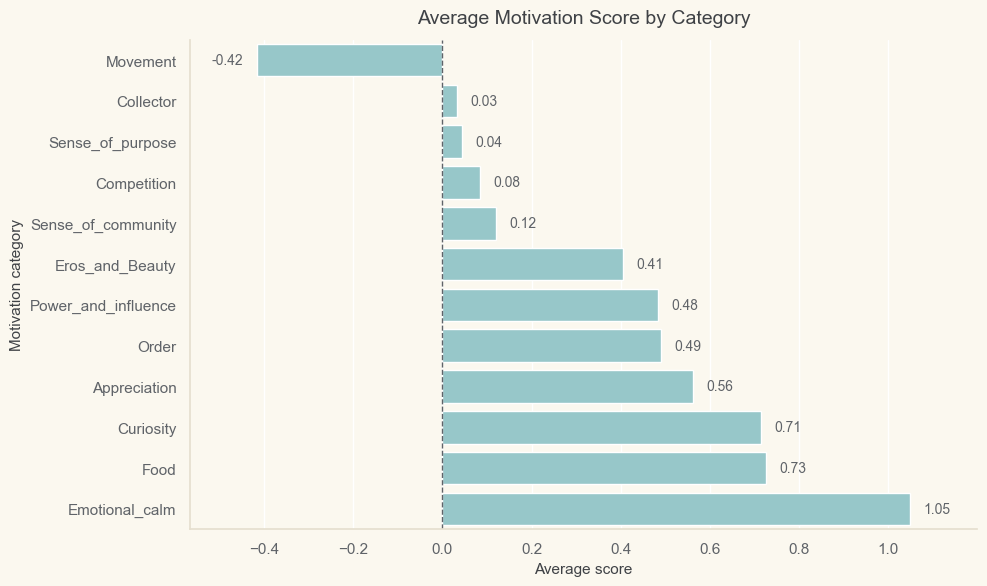

In [9]:
motivation_means = (df[motivation_cols]
                    .mean()
                    .sort_values(ascending=True)
                   )

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x = motivation_means.values,
            y = motivation_means.index,
            color = PALETTE_MOTIVATION["teal"],
            ax = ax
        )

ax.axvline(0,
           color=PALETTE_MOTIVATION["gray"],
           linestyle="--",
           linewidth=1)

ax.set_title("Average Motivation Score by Category", pad=12)
ax.set_xlabel("Average score")
ax.set_ylabel("Motivation category")

x_min = motivation_means.min() - 0.15
x_max = motivation_means.max() + 0.15
ax.set_xlim(x_min, x_max)

for i, value in enumerate(motivation_means.values):
    if value >= 0:
        ax.text(value + 0.03,
                i,
                f"{value:.2f}",
                va = "center",
                ha = "left",
                color = PALETTE_MOTIVATION["gray"],
                fontsize = 10
            )
    else:
        ax.text(value - 0.03,
                i,
                f"{value:.2f}",
                va = "center",
                ha = "right",
                color = PALETTE_MOTIVATION["gray"],
                fontsize = 10
            )

sns.despine(ax=ax,
            left=False,
            bottom=False)

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Average Motivation Score Interpretation**

`Emotional_calm` has the highest average score across participants, followed by `Food`, `Curiosity`, `Appreciation`, and `Order`. This suggests that these motivations tend to be more strongly represented in the sample.

`Movement` is the only motivation category with a clearly negative average score, indicating that participants scored lower on this dimension compared with the other motivations.

Several categories, such as `Collector`, `Sense_of_purpose`, `Competition`, and `Sense_of_community`, have averages close to zero. These motivations may vary more across individuals and could be useful for distinguishing participant profiles during clustering.

This first view suggests that the dataset contains differences in average motivation levels, but clustering will depend not only on averages, but also on how combinations of motivations vary across participants.

</div>


### **Distribution of Motivation Scores by Category**


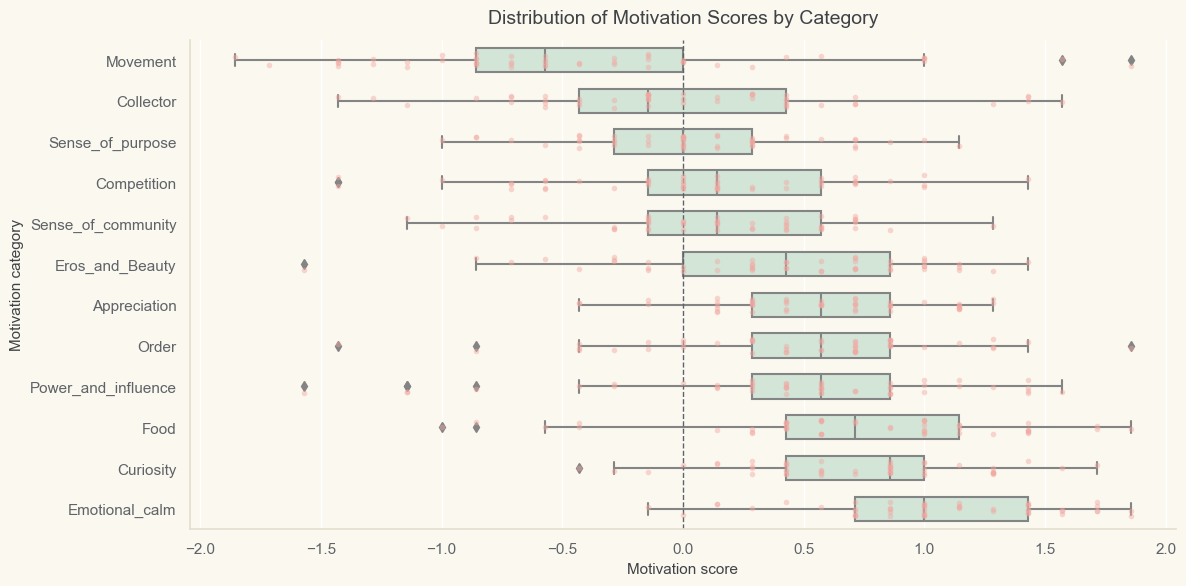

In [10]:
df_melted = df[motivation_cols].melt(var_name="Motivation category",
                                     value_name="Score"
                                    )

category_order = (df_melted.groupby("Motivation category")["Score"]
                           .median()
                           .sort_values(ascending=True)
                           .index
                 )


fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data = df_melted,
            x = "Score",
            y = "Motivation category",
            order = category_order,
            color = PALETTE_MOTIVATION["mint"],
            width = 0.6,
            ax = ax
           )

sns.stripplot(data = df_melted,
              x = "Score",
              y = "Motivation category",
              order = category_order,
              color = PALETTE_MOTIVATION["coral"],
              size = 4,
              alpha = 0.45,
              jitter = 0.18,
              ax = ax
             )

ax.axvline(0,
           color = PALETTE_MOTIVATION["gray"],
           linestyle = "--",
           linewidth = 1
           )

ax.set_title("Distribution of Motivation Scores by Category", pad=12)
ax.set_xlabel("Motivation score")
ax.set_ylabel("Motivation category")

sns.despine(ax=ax,
            left=False,
            bottom=False
            )

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Distribution of Motivation Scores Interpretation**

The distributions show that motivation categories differ not only in their average level, but also in their variability across participants.

`Emotional_calm`, `Food`, and `Curiosity` tend to have higher scores for many participants, while `Movement` is shifted toward lower values and has a wider range. This suggests that `Movement` may help distinguish participants with different motivation profiles.

Some categories, such as `Collector`, `Competition`, `Sense_of_purpose`, and `Sense_of_community`, show values spread around zero. These variables may be useful for separating participants because they capture differences that are not visible from the average score alone.

The presence of wide spreads and individual extreme values reinforces the need to scale the data before applying distance-based clustering methods.
</div>

### **Correlation Between Motivation Categories**


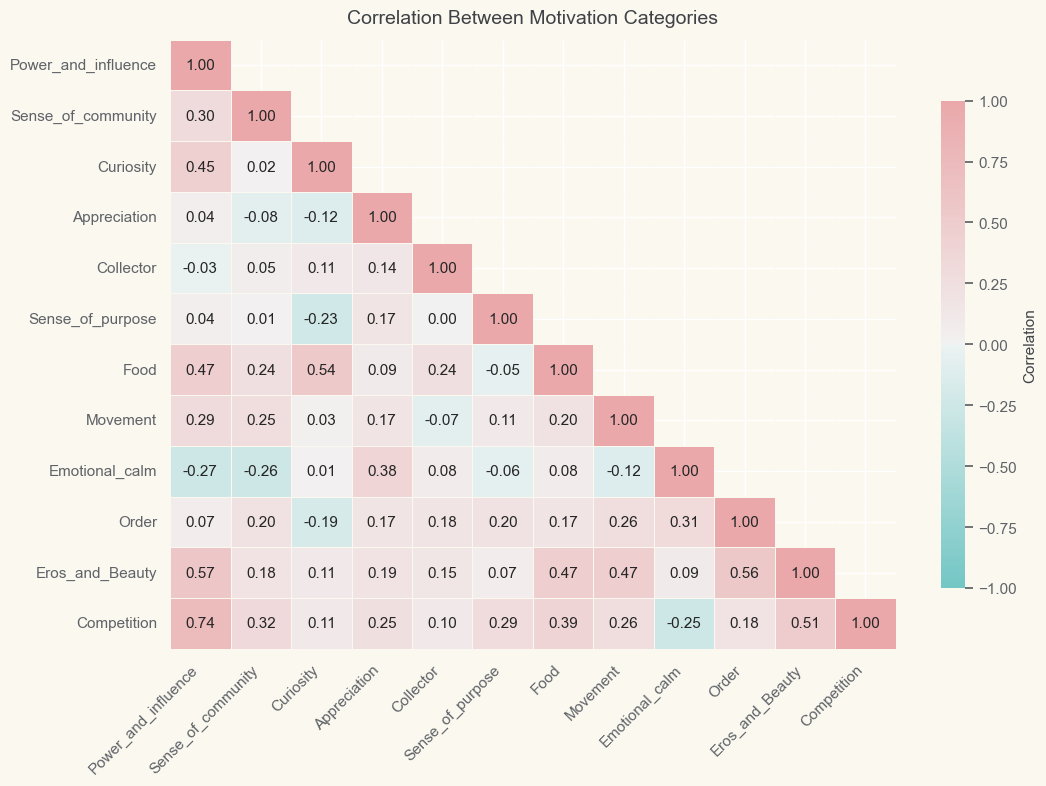

In [11]:
corr_matrix = df[motivation_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype = bool), k = 1)

fig, ax = plt.subplots(figsize = (11, 8))

cmap = sns.diverging_palette(190,
                             10,
                             s = 65,
                             l = 75,
                             as_cmap = True
                            )

sns.heatmap(corr_matrix,
            mask = mask,
            annot = True,
            fmt = ".2f",
            cmap = cmap,
            center = 0,
            vmin = -1,
            vmax = 1,
            linewidths = 0.7,
            linecolor = PALETTE_MOTIVATION["cream"],
            cbar_kws = {"shrink": 0.8, "label": "Correlation"},
            ax = ax
        )

ax.set_title("Correlation Between Motivation Categories", pad=12)

plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Correlation Interpretation**

The correlation heatmap shows several moderate positive relationships between motivation categories.

The strongest relationship is between `Power_and_influence` and `Competition` with a correlation of 0.74. This suggests that participants who score higher in power/influence also tend to score higher in competition.

Other relevant positive relationships include:

- `Power_and_influence` and `Eros_and_Beauty` (0.57)
- `Order` and `Eros_and_Beauty` (0.56)
- `Curiosity` and `Food` (0.54)
- `Eros_and_Beauty` and `Competition` (0.51)
- `Food` and `Power_and_influence` (0.47)
- `Food` and `Eros_and_Beauty` (0.47)
- `Movement` and `Eros_and_Beauty` (0.47)

Most negative correlations are weak to moderate. For example, `Emotional_calm` has negative correlations with `Power_and_influence` (-0.27), `Sense_of_community` (-0.26), and `Competition` (-0.25). This may suggest that participants with stronger competitive or power-oriented motivations tend to score slightly lower in emotional calm, although the relationships are not strong enough to draw firm conclusions.

This analysis supports the second project question: some motivation categories appear to move together and may form interpretable groups. However, correlation alone is not enough to define clusters. Clustering methods will be used later to explore whether these relationships lead to stable motivation-category groups.

</div>


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Preprocessing for Clustering**

</div>

Clustering algorithms are sensitive to how distances are calculated between observations. Even when variables are measured on a similar scale, preprocessing helps make the analysis more consistent and reproducible.

In this project:

- `Patient_ID` is removed from the feature matrix because it is only an identifier.
- The motivation variables are kept as numerical features.
- The data is standardized before distance-based clustering so that each motivation contributes fairly to the distance calculation.


In [12]:
X = df[motivation_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled,
                        columns=motivation_cols,
                        index=df["Patient_ID"]
                       )

display(X_scaled.head())

print("Scaled feature matrix shape:", X_scaled.shape)


,Power_and_influence,Sense_of_community,Curiosity,Appreciation,Collector,Sense_of_purpose,Food,Movement,Emotional_calm,Order,Eros_and_Beauty,Competition
Patient_ID,,,,,,,,,,,,
P1,-1.355830,-0.776064,-2.455762,-2.334689,-0.463935,-0.092522,-1.835735,-0.360954,-2.186764,-1.541675,-1.129391,-0.606843
P2,-0.294557,0.044666,0.613941,-0.652340,0.787412,-0.999239,1.117202,-1.748150,0.194379,-1.541675,-0.195380,-0.372707
P3,1.191224,0.865395,-0.920911,0.357070,0.578854,0.814195,1.117202,1.199641,0.789665,0.856486,1.205637,1.032111
P4,1.403479,-0.502488,0.920911,-0.315870,0.578854,-0.092522,0.890053,0.159244,0.789665,0.616670,0.972134,0.797975
P5,-0.719066,-0.228911,-0.613941,0.357070,0.370297,0.511956,0.435755,-0.534353,0.492022,0.616670,-0.428883,-0.372707


Scaled feature matrix shape: (49, 12)


In [13]:
scaled_summary = X_scaled.describe().T[["mean", "std"]].round(2)
display(scaled_summary)


,mean,std
Power_and_influence,0.0,1.01
Sense_of_community,0.0,1.01
Curiosity,-0.0,1.01
Appreciation,0.0,1.01
Collector,-0.0,1.01
Sense_of_purpose,-0.0,1.01
Food,0.0,1.01
Movement,0.0,1.01
Emotional_calm,0.0,1.01
Order,-0.0,1.01


### **Preprocessing Summary**

`Patient_ID` was removed from the clustering feature matrix because it is an identifier and does not represent a motivation score.

The 12 motivation variables were standardized using `StandardScaler`. After scaling, each feature has a mean close to 0 and a standard deviation close to 1.

This preprocessing step is important because several methods used in this project, including K-Means, hierarchical clustering, DBSCAN, and PCA visualization, depend on distance, variance, or feature-scale structure. Standardizing the variables helps ensure that differences in variance do not make one motivation category dominate the analysis.


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Dimensionality Reduction for Visualization**

</div>

The motivation dataset contains 12 numerical features, one for each motivation category. Clustering algorithms can use this full feature space, but it is difficult to visually inspect patterns in 12 dimensions.

Dimensionality reduction is used here to project the data into two dimensions so that participant patterns can be explored visually.

In this section, PCA is used as an exploratory visualization tool. The PCA plot does not prove the final cluster structure, but it helps show whether participants appear separated, overlapping, or unusual before applying clustering algorithms.


In [14]:
pca = PCA(n_components = 2, random_state = 42)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca,
                      columns=["PC1", "PC2"],
                      index=X_scaled.index
                     )

explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1:", round(explained_variance[0], 3))
print("Explained variance by PC2:", round(explained_variance[1], 3))
print("Total explained variance:", round(explained_variance.sum(), 3))

display(df_pca.head())


Explained variance by PC1: 0.278
Explained variance by PC2: 0.159
Total explained variance: 0.436


,PC1,PC2
Patient_ID,,
P1,3.410795,1.444623
P2,0.811793,1.510795
P3,-2.664928,-1.285861
P4,-1.941807,0.020745
P5,0.584641,-1.151912


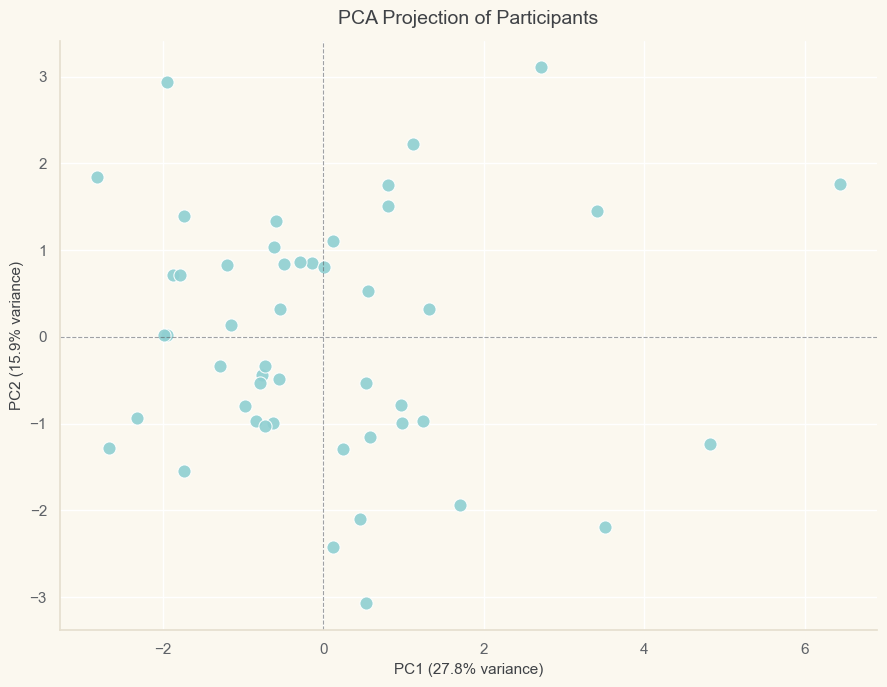

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(data = df_pca,
                x = "PC1",
                y = "PC2",
                s = 90,
                color = PALETTE_MOTIVATION["teal"],
                edgecolor = "white",
                linewidth = 0.8,
                alpha = 0.9,
                ax = ax
            )

ax.axhline(0,
           color = PALETTE_MOTIVATION["gray"],
           linestyle = "--",
           linewidth = 0.8,
           alpha = 0.6
           )

ax.axvline(0,
           color = PALETTE_MOTIVATION["gray"],
           linestyle = "--",
           linewidth = 0.8,
           alpha = 0.6
           )

ax.set_title("PCA Projection of Participants", pad=12)
ax.set_xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% variance)")

sns.despine(ax = ax,
            left = False,
            bottom = False)

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **PCA Projection Interpretation**

The first two principal components explain approximately 43.7% of the total variance in the standardized motivation scores.

This means that the 2D PCA projection captures part of the structure in the data, but not the full 12-dimensional motivation space. Therefore, _the plot should be used as an exploratory visualization rather than as definitive evidence of cluster structure._

The projection shows that most participants are concentrated around the central-left area, while a few participants appear more separated, especially toward the right side of PC1 and the lower part of PC2.

This suggests that there may be some differences in motivation profiles across participants, but the groups are not visually separated into very clear clusters in the first two principal components. **Clustering methods will be needed to test whether meaningful participant segments can be identified.**
</div>


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Participant Clustering with K-Means**

</div>

K-Means is used as a first clustering approach to group participants according to similarity in their motivation profiles.

Because K-Means requires the number of clusters to be specified in advance, I evaluate several values of `k` using two complementary criteria:

- **Inertia**, which measures within-cluster compactness.
- **Silhouette score**, which measures how well each participant fits within its assigned cluster compared with other clusters.

The goal is not to choose `k` mechanically, but to find a solution that is both statistically reasonable and interpretable.


In [16]:
k_values = range(2, 11)

kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters = k,
                   random_state = 42,
                   n_init = 20
                  )

    labels = model.fit_predict(X_scaled)

    inertia = model.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    kmeans_results.append({"k": k,
                           "inertia": inertia,
                           "silhouette_score": silhouette
                          }
                         )

kmeans_results = pd.DataFrame(kmeans_results)

display(kmeans_results.round(3))


,k,inertia,silhouette_score
0,2,484.767,0.325
1,3,424.232,0.123
2,4,372.956,0.142
3,5,350.888,0.106
4,6,329.731,0.101
5,7,305.482,0.117
6,8,287.766,0.109
7,9,277.300,0.109
8,10,256.651,0.120


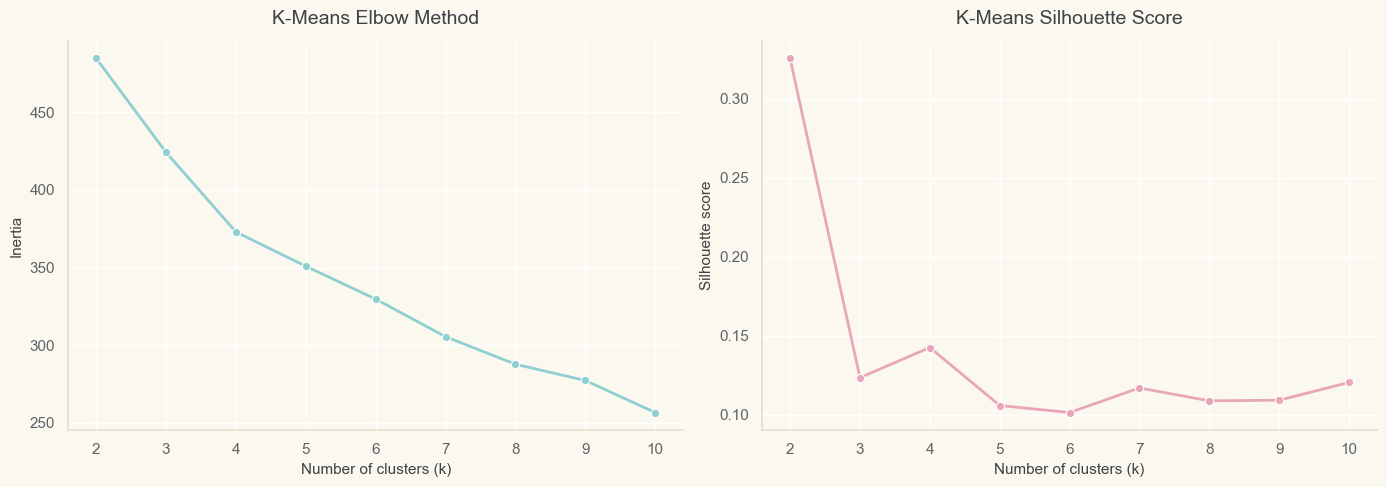

In [17]:
fig, axes = plt.subplots(nrows = 1,
                         ncols = 2,
                         figsize = (14, 5))

sns.lineplot(data = kmeans_results,
             x = "k",
             y = "inertia",
             marker = "o",
             color = PALETTE_MOTIVATION["teal"],
             linewidth = 2,
             ax = axes[0]
            )

axes[0].set_title("K-Means Elbow Method", pad=12)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

sns.lineplot(data = kmeans_results,
             x = "k",
             y = "silhouette_score",
             marker = "o",
             color = PALETTE_MOTIVATION["pink"],
             linewidth = 2,
             ax = axes[1]
            )

axes[1].set_title("K-Means Silhouette Score", pad = 12)
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

for ax in axes:
    ax.set_xticks(list(k_values))
    sns.despine(ax = ax,
                left = False,
                bottom = False)

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **K-Means Cluster Number Evaluation**

The K-Means evaluation suggests that `k = 2` is the most defensible initial candidate among the tested values.

The silhouette score is highest for `k = 2` with a value of 0.325. This indicates the clearest separation among the tested values of `k`, although the separation is still moderate rather than strong.

For `k >= 3`, the silhouette scores drop substantially and remain low, suggesting that additional clusters may split the data into less well-separated groups.

The inertia curve decreases as expected when more clusters are added, but it does not show a very clear elbow. Because inertia always decreases with increasing `k`, it should not be used alone to choose the number of clusters.

Based on the combination of silhouette score, inertia behavior, and interpretability, `k = 2` will be used as the initial K-Means clustering solution.
</div>


In [18]:
# Fit final K-Means model using the selected number of clusters
kmeans_final = KMeans(n_clusters = 2,
                      random_state = 42,
                      n_init = 20
                     )

kmeans_labels = kmeans_final.fit_predict(X_scaled)

df_kmeans = df.copy()
df_kmeans["KMeans_cluster"] = kmeans_labels

df_pca_kmeans = df_pca.copy()
df_pca_kmeans["KMeans_cluster"] = kmeans_labels.astype(str)

display(df_kmeans[["Patient_ID", "KMeans_cluster"]].head())

print("Cluster sizes:")
print(df_kmeans["KMeans_cluster"].value_counts().sort_index())


,Patient_ID,KMeans_cluster
0,P1,0
1,P2,1
2,P3,1
3,P4,1
4,P5,1


Cluster sizes:
KMeans_cluster
0     5
1    44
Name: count, dtype: int64


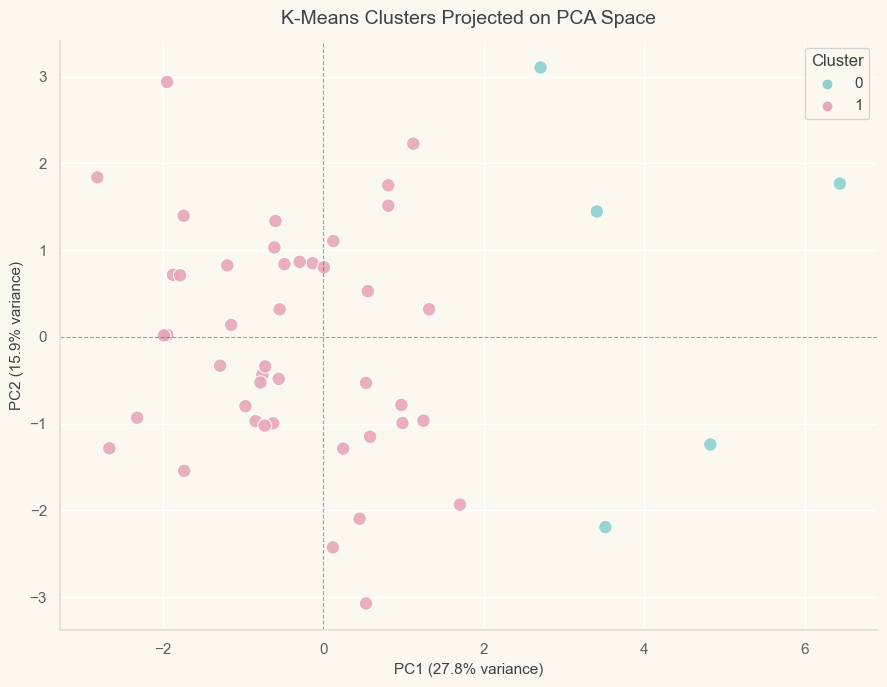

In [19]:
# PCA visualization

fig, ax = plt.subplots(figsize = (9, 7))

sns.scatterplot(data = df_pca_kmeans,
                x = "PC1",
                y = "PC2",
                hue = "KMeans_cluster",
                palette = [PALETTE_MOTIVATION["teal"], PALETTE_MOTIVATION["pink"]],
                s = 95,
                edgecolor = "white",
                linewidth = 0.8,
                alpha = 0.9,
                ax = ax
               )

ax.axhline(0, color=PALETTE_MOTIVATION["gray"], linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(0, color=PALETTE_MOTIVATION["gray"], linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title("K-Means Clusters Projected on PCA Space", pad=12)
ax.set_xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% variance)")
ax.legend(title="Cluster")

sns.despine(ax=ax,
            left=False,
            bottom=False)

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Initial K-Means Result**

The K-Means model with `k = 2` separates the participants into two very uneven groups: one small cluster with 5 participants and one larger cluster with 44 participants.

In the PCA projection, the small cluster appears mostly on the right side of PC1, while the larger cluster contains most participants and is more spread across the central area of the plot.

This suggests that K-Means is identifying a small group of participants with motivation profiles that differ from the majority. However, because the cluster sizes are highly imbalanced, this result should be interpreted cautiously. The small cluster may represent a meaningful niche profile, but it may also reflect outlying or unusual observations.

The next step is to profile both clusters by comparing their average motivation scores.

</div>


In [20]:
# Profile the clusters

cluster_profile = (df_kmeans
                   .groupby("KMeans_cluster")[motivation_cols]
                   .mean()
                   .round(2)
                  )

display(cluster_profile)


,Power_and_influence,Sense_of_community,Curiosity,Appreciation,Collector,Sense_of_purpose,Food,Movement,Emotional_calm,Order,Eros_and_Beauty,Competition
KMeans_cluster,,,,,,,,,,,,
0,-0.77,-0.49,0.37,0.03,-0.43,-0.06,-0.29,-1.09,0.94,-0.23,-0.71,-0.97
1,0.63,0.19,0.75,0.62,0.08,0.06,0.84,-0.34,1.06,0.57,0.53,0.20


In [21]:
# Profile the clusters using standardized

cluster_profile_scaled = X_scaled.copy()
cluster_profile_scaled["KMeans_cluster"] = kmeans_labels

cluster_profile_scaled = (cluster_profile_scaled
                          .groupby("KMeans_cluster")
                          .mean()
                          .round(2)
                         )

display(cluster_profile_scaled)

,Power_and_influence,Sense_of_community,Curiosity,Appreciation,Collector,Sense_of_purpose,Food,Movement,Emotional_calm,Order,Eros_and_Beauty,Competition
KMeans_cluster,,,,,,,,,,,,
0,-1.87,-1.16,-0.74,-1.26,-0.67,-0.21,-1.61,-0.81,-0.22,-1.21,-1.83,-1.73
1,0.21,0.13,0.08,0.14,0.08,0.02,0.18,0.09,0.03,0.14,0.21,0.20


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **K-Means Cluster Profile Interpretation**

The standardized cluster profile shows that Cluster 0 is a small group of 5 participants with consistently lower motivation scores across several dimensions.

Compared with the overall sample average, Cluster 0 is especially lower in:

- `Power_and_influence`
- `Food`
- `Eros_and_Beauty`
- `Competition`
- `Appreciation`
- `Order`
- `Sense_of_community`

Cluster 1 contains 44 participants and stays close to the overall sample average across most motivation categories. This is expected because it contains most of the participants.

Based on this profile, the K-Means solution seems to separate a small low-motivation/distinct-profile group from the broader participant group. However, because Cluster 0 contains only 5 participants, it should be interpreted as an exploratory segment rather than a definitive population group.

A possible interpretation is:

- **Cluster 0:** Low overall motivation profile
- **Cluster 1:** Mainstream/balanced motivation profile

</div>

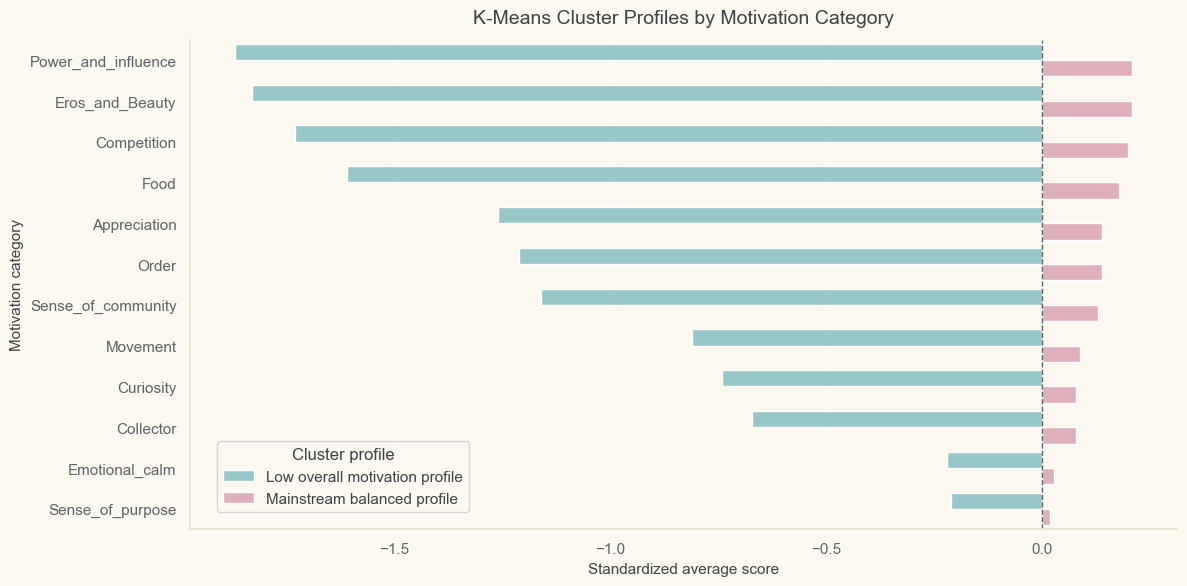

In [22]:
# Profile plot

cluster_name_map = {0: "Low overall motivation profile",
                    1: "Mainstream balanced profile"
                   }

cluster_profile_plot = (cluster_profile_scaled.T
                                              .reset_index()
                                              .rename(columns = {"index": "Motivation category"})
                       )

cluster_profile_plot = cluster_profile_plot.melt(id_vars = "Motivation category",
                                                 var_name = "KMeans_cluster",
                                                 value_name = "Standardized average"
                                                )

cluster_profile_plot["Cluster profile"] = (cluster_profile_plot["KMeans_cluster"].map(cluster_name_map))

category_order = (cluster_profile_scaled.loc[0].sort_values(ascending = True)
                                               .index
                 )

fig, ax = plt.subplots(figsize = (12, 6))

sns.barplot(data = cluster_profile_plot,
            x = "Standardized average",
            y = "Motivation category",
            hue = "Cluster profile",
            order = category_order,
            palette = [PALETTE_MOTIVATION["teal"], PALETTE_MOTIVATION["pink"]],
            ax = ax
          )

ax.axvline(0,
           color = PALETTE_MOTIVATION["gray"],
           linestyle = "--",
           linewidth = 1
           )

ax.set_title("K-Means Cluster Profiles by Motivation Category", pad = 12)
ax.set_xlabel("Standardized average score")
ax.set_ylabel("Motivation category")
ax.legend(title = "Cluster profile",
          loc = "lower left",
          bbox_to_anchor = (0.02, 0.02),
          frameon = True
         )


sns.despine(ax = ax,
            left = False,
            bottom = False)

plt.tight_layout()
plt.show()


The cluster labels are descriptive names assigned after profiling the clusters. K-Means itself only produces numerical labels, and the numbers `0` and `1` do not have an inherent meaning.


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **K-Means Clustering Conclusion**

K-Means identified two participant groups, but the solution is highly imbalanced: one small cluster with 5 participants and one large cluster with 44 participants.

The small cluster shows consistently lower standardized scores across most motivation categories, especially in `Power_and_influence`, `Eros_and_Beauty`, `Competition`, `Food`, `Appreciation`, `Order`, and `Sense_of_community`. This suggests a distinct low overall motivation profile.

The larger cluster stays close to the sample average across most motivation categories and can be interpreted as the mainstream or balanced motivation profile.

Because the sample size is small and one cluster contains only 5 participants, this K-Means result should be treated as exploratory. The next step is to compare it with another clustering approach, such as hierarchical clustering, to check whether a similar structure appears.
</div>


<div style="color:white; background-color:  #b2cdcd; padding: 10px;">

## **Comparing Clustering Approaches**

</div>

The K-Means model provided an initial segmentation of participants, but the result should be validated with additional clustering approaches before drawing final conclusions.

This comparison is important because different clustering algorithms make different assumptions about the structure of the data:

- **K-Means** assumes that clusters are relatively compact and separated around centroids. It also requires the number of clusters to be specified in advance.
- **Hierarchical clustering** builds a tree of similarities between participants and is useful for small datasets because the dendrogram allows the cluster structure to be inspected visually.
- **DBSCAN** groups observations based on density and can identify observations that do not clearly belong to any dense group. This is useful for checking whether the small K-Means cluster behaves like a real dense segment or more like a set of unusual profiles. However, _DBSCAN must be interpreted carefully here because the dataset is small and has 12 dimensions, which can make density-based clustering less stable._


Using these methods together helps evaluate whether the participant segments are stable across different assumptions.

In this project, the comparison is especially relevant because K-Means produced a highly imbalanced solution with one small cluster of 5 participants and one large cluster of 44 participants. Hierarchical clustering can help inspect whether this separation appears naturally in the distance structure, while DBSCAN can help assess whether some participants may be better interpreted as noise or outliers rather than as a separate cluster.

_Because the dataset is small and has 12 dimensions, the results will be interpreted cautiously. The goal is not to force a perfect clustering solution, but to identify whether the motivation profiles show meaningful structure._


### **Participant Clustering with Hierarchical Clustering**

Hierarchical clustering is used as a complementary method to K-Means.

Unlike K-Means, hierarchical clustering does not assign participants to a fixed number of clusters immediately. Instead, it builds a hierarchy of similarities between participants, which can be visualized with a dendrogram.

This is useful in this project because the dataset is small and the K-Means solution produced a very small cluster. The dendrogram helps inspect whether this small group appears naturally separated from the rest of the participants.


For hierarchical clustering, I use Ward linkage.

Ward linkage merges observations or clusters by minimizing the increase in within-cluster variance at each step. This means it tends to create compact and relatively homogeneous groups.

This choice is appropriate here because the motivation variables are numerical and standardized, and because it provides a useful comparison with K-Means, which also favors compact clusters around central profiles.


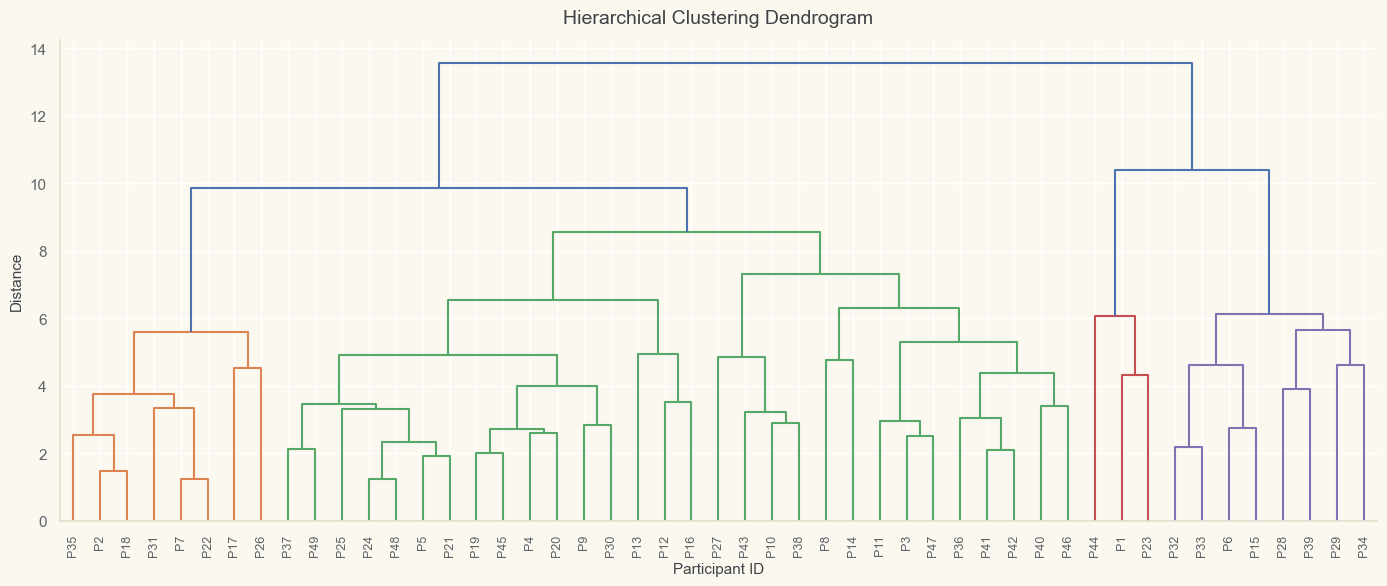

In [23]:
linkage_matrix = linkage(X_scaled,
                         method = "ward"
                       )

fig, ax = plt.subplots(figsize = (14, 6))

dendrogram(linkage_matrix,
           labels = X_scaled.index.astype(str).tolist(),
           leaf_rotation = 90,
           leaf_font_size = 9,
           color_threshold = None,
           ax = ax
          )

ax.set_title("Hierarchical Clustering Dendrogram",
             pad = 12)
ax.set_xlabel("Participant ID")
ax.set_ylabel("Distance")

sns.despine(ax = ax,
            left = False,
            bottom = False
            )

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Hierarchical Dendrogram Interpretation**

The dendrogram shows how participants are progressively grouped according to similarity in their standardized motivation profiles.

The highest split separates the data into two broad branches, suggesting that a two-cluster structure is a reasonable first option to compare with the K-Means result. However, the dendrogram also shows several smaller sub-branches within those two broad groups. This indicates that the motivation profiles may contain more nuanced subgroups, even if the main separation is not extremely sharp.

Compared with K-Means, the hierarchical structure does not simply isolate the same small group visually. Instead, it suggests a broader hierarchy of participant similarities. For this reason, the next step is to cut the dendrogram into two clusters and compare the resulting labels with the K-Means labels.

This comparison will help evaluate whether the two methods identify a similar participant structure or whether K-Means is mainly isolating a small set of unusual profiles.
</div>


In [24]:
# Create the hierarchical cluster labels with n_clusters=2

hierarchical_model = AgglomerativeClustering(n_clusters = 2,
                                             linkage = "ward"
                                            )

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

df_hierarchical = df.copy()
df_hierarchical["Hierarchical_cluster"] = hierarchical_labels

print("Hierarchical cluster sizes:")
print(df_hierarchical["Hierarchical_cluster"].value_counts().sort_index())


Hierarchical cluster sizes:
Hierarchical_cluster
0    11
1    38
Name: count, dtype: int64


In [25]:
# Compare the labels with K-Means

cluster_comparison = pd.crosstab(df_kmeans["KMeans_cluster"],
                                 df_hierarchical["Hierarchical_cluster"],
                                 rownames = ["K-Means cluster"],
                                 colnames = ["Hierarchical cluster"]
                                )

display(cluster_comparison)


Hierarchical cluster,0,1
K-Means cluster,,
0,4,1
1,7,37


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Comparison Between K-Means and Hierarchical Clustering**

The hierarchical clustering solution with two clusters produced a less extreme split than K-Means.

K-Means created one small cluster with 5 participants and one large cluster with 44 participants. Hierarchical clustering created a minority cluster with 11 participants and a majority cluster with 38 participants.

The cross-tabulation shows partial agreement between the two methods. Four of the five participants assigned to the small K-Means cluster are also assigned to the minority hierarchical cluster. This suggests that the small K-Means group is not arbitrary; most of it is also identified as different by hierarchical clustering.

However, hierarchical clustering includes seven additional participants in the minority group. This indicates that the hierarchical method captures a broader version of the lower/distinct motivation profile, while K-Means isolates a more extreme subset.

**Overall, the comparison supports the existence of a smaller group of participants with different motivation profiles, but the exact size of that group depends on the clustering method.**

</div>


Because both methods identify a smaller group of participants, but disagree on its exact size, the next step is to profile the hierarchical clusters.

This will show whether the minority hierarchical cluster has a similar motivation pattern to the small K-Means cluster, or whether it represents a different type of participant segment.


In [26]:
hierarchical_profile_scaled = X_scaled.copy()
hierarchical_profile_scaled["Hierarchical_cluster"] = hierarchical_labels

hierarchical_profile_scaled = (hierarchical_profile_scaled.groupby("Hierarchical_cluster")
                                                          .mean()
                                                          .round(2)
                              )

display(hierarchical_profile_scaled)


,Power_and_influence,Sense_of_community,Curiosity,Appreciation,Collector,Sense_of_purpose,Food,Movement,Emotional_calm,Order,Eros_and_Beauty,Competition
Hierarchical_cluster,,,,,,,,,,,,
0,-1.30,-0.45,-1.17,0.14,-0.39,0.26,-1.15,-0.28,0.33,-0.12,-0.75,-0.95
1,0.38,0.13,0.34,-0.04,0.11,-0.08,0.33,0.08,-0.10,0.04,0.22,0.27


In [27]:
# Version with original scale

hierarchical_profile_raw = df_hierarchical.copy()

hierarchical_profile_raw = (hierarchical_profile_raw.groupby("Hierarchical_cluster")[motivation_cols]
                                                    .mean()
                                                    .round(2)
                           )

display(hierarchical_profile_raw)


,Power_and_influence,Sense_of_community,Curiosity,Appreciation,Collector,Sense_of_purpose,Food,Movement,Emotional_calm,Order,Eros_and_Beauty,Competition
Hierarchical_cluster,,,,,,,,,,,,
0,-0.39,-0.12,0.17,0.62,-0.23,0.17,-0.00,-0.65,1.21,0.42,-0.05,-0.49
1,0.74,0.19,0.87,0.55,0.11,0.01,0.94,-0.35,1.00,0.51,0.54,0.25


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Hierarchical Cluster Profile Interpretation**

The hierarchical clustering profile confirms that the smaller group differs meaningfully from the majority group, but it also provides a more nuanced view than K-Means.

Hierarchical Cluster 0 contains 11 participants. Compared with the overall sample average, this group scores lower in several motivation categories, especially:

- `Power_and_influence`
- `Curiosity`
- `Food`
- `Eros_and_Beauty`
- `Competition`

However, this group is not simply lower across every dimension. It has slightly higher standardized scores in `Emotional_calm` and `Sense_of_purpose`. This suggests that the group may be better described as having lower drive/exploration-oriented motivations rather than lower motivation overall.

Hierarchical Cluster 1 contains 38 participants and shows higher scores in `Power_and_influence`, `Curiosity`, `Food`, `Eros_and_Beauty`, and `Competition`. This group can be interpreted as having a stronger drive/exploration-oriented motivation profile.

A possible interpretation is:

- **Hierarchical Cluster 0:** Lower drive/exploration profile
- **Hierarchical Cluster 1:** Higher drive/exploration profile
</div>


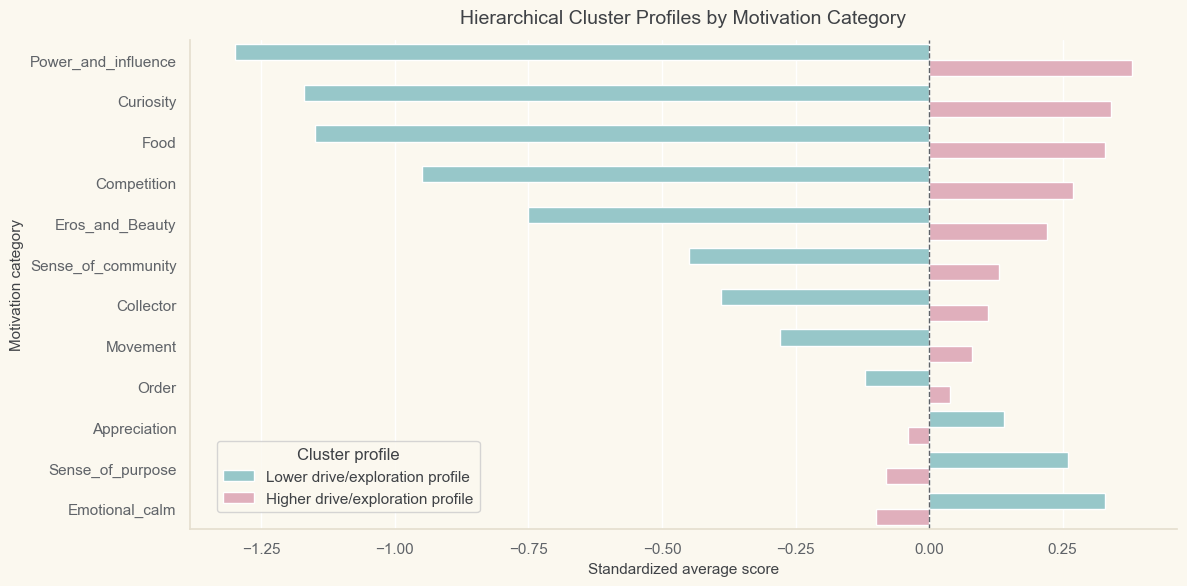

In [28]:
# Hierarchical Profile Plot:

hierarchical_cluster_name_map = {0: "Lower drive/exploration profile",
                                 1: "Higher drive/exploration profile"
                                }

hierarchical_profile_plot = (hierarchical_profile_scaled.T
                                                        .reset_index()
                                                        .rename(columns = {"index": "Motivation category"})
                            )

hierarchical_profile_plot = hierarchical_profile_plot.melt(id_vars = "Motivation category",
                                                           var_name = "Hierarchical_cluster",
                                                           value_name = "Standardized average"
                                                          )

hierarchical_profile_plot["Cluster profile"] = (hierarchical_profile_plot["Hierarchical_cluster"].map(hierarchical_cluster_name_map)
)

category_order = (hierarchical_profile_scaled.loc[0].sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data = hierarchical_profile_plot,
            x = "Standardized average",
            y = "Motivation category",
            hue = "Cluster profile",
            order = category_order,
            palette = [PALETTE_MOTIVATION["teal"], PALETTE_MOTIVATION["pink"]],
            ax = ax
           )

ax.axvline(0,
           color=PALETTE_MOTIVATION["gray"],
           linestyle = "--",
           linewidth = 1
          )

ax.set_title("Hierarchical Cluster Profiles by Motivation Category",
             pad = 12)
ax.set_xlabel("Standardized average score")
ax.set_ylabel("Motivation category")

ax.legend(title = "Cluster profile",
          loc = "lower left",
          bbox_to_anchor = (0.02, 0.02),
          frameon = True
         )

sns.despine(ax = ax,
            left = False,
            bottom = False)

plt.tight_layout()
plt.show()


The hierarchical profile plot shows that the smaller group is mainly lower in drive-, exploration-, and reward-oriented categories such as `Power_and_influence`, `Curiosity`, `Food`, `Competition`, and `Eros_and_Beauty`.

However, this group is not uniformly lower across all motivations. It scores slightly higher in `Emotional_calm` and `Sense_of_purpose`, which suggests a more specific profile rather than a general lack of motivation.

This makes the hierarchical solution more nuanced than the K-Means solution. K-Means isolated a smaller and more extreme low-overall profile, while hierarchical clustering identified a broader group characterized by lower drive/exploration scores but relatively stronger calm/purpose-related motivations.


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Hierarchical Clustering Conclusion**

Hierarchical clustering supports the idea that a smaller participant group differs from the majority, but it defines this group more broadly than K-Means.

The comparison suggests that the small K-Means cluster may represent the most extreme part of a broader lower drive/exploration profile identified by hierarchical clustering.

Because hierarchical clustering provides a more nuanced and less extreme split, it is useful as a complementary interpretation rather than a replacement for K-Means.
</div>


### **Participant Clustering with DBSCAN**

DBSCAN is used as a third clustering approach to test whether the participant profiles form dense groups or whether some participants behave more like unusual observations.

Unlike K-Means and hierarchical clustering, DBSCAN does not require specifying the number of clusters in advance. Instead, it uses two parameters:

- `eps`: the maximum distance between points to be considered neighbors.
- `min_samples`: the minimum number of nearby points required to form a dense region.

DBSCAN can be useful for detecting dense groups of participants and identifying observations that do not clearly belong to any dense region.

However, in this project DBSCAN should be interpreted cautiously. The dataset contains only 49 participants and 12 standardized motivation variables. With a small sample size, density estimates can be unstable, and in higher-dimensional spaces distances between observations can become less informative. As a result, DBSCAN may fail to identify stable clusters or may classify many participants as noise.

For this reason, DBSCAN is used here as an exploratory robustness check rather than as the main clustering method.


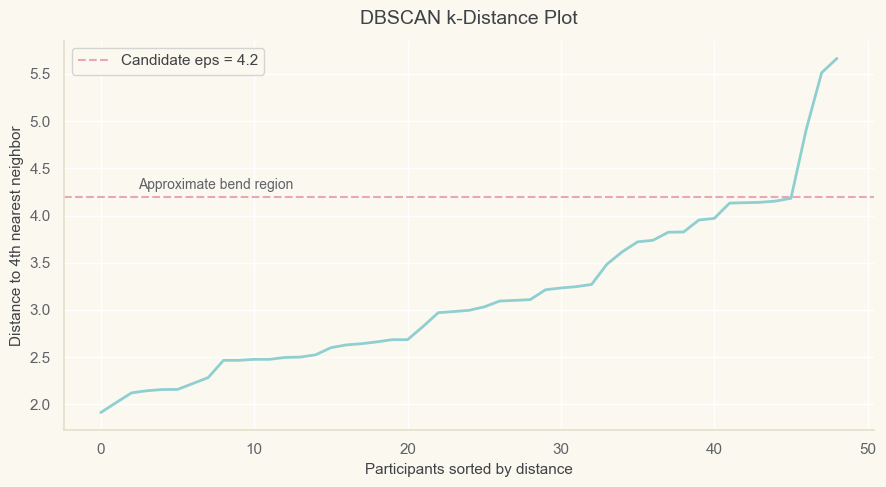

In [29]:
min_samples = 4

nearest_neighbors = NearestNeighbors(n_neighbors = min_samples)
nearest_neighbors.fit(X_scaled)

distances, indices = nearest_neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

eps_candidate = 4.2

fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(x = np.arange(len(k_distances)),
             y = k_distances,
             color = PALETTE_MOTIVATION["teal"],
             linewidth = 2,
             ax = ax
            )

ax.axhline(eps_candidate,
           color = PALETTE_MOTIVATION["pink"],
           linestyle = "--",
           linewidth = 1.5,
           label = f"Candidate eps = {eps_candidate}"
          )

ax.text(x = len(k_distances) * 0.05,
        y = eps_candidate + 0.08,
        s = "Approximate bend region",
        color = PALETTE_MOTIVATION["gray"],
        fontsize = 10
       )

ax.set_title("DBSCAN k-Distance Plot", pad=12)
ax.set_xlabel("Participants sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}th nearest neighbor")
ax.legend(loc = "upper left")

sns.despine(ax = ax,
            left = False,
            bottom = False)

plt.tight_layout()
plt.show()



The horizontal line marks an approximate candidate value for `eps`, not a fixed rule. It is used as a starting point for sensitivity testing around nearby values.


### **DBSCAN Sensitivity Test**

Because the `eps` value is selected approximately from the k-distance plot, I test a small range of nearby values instead of relying on a single parameter setting.

This helps evaluate whether DBSCAN finds a stable clustering structure or whether the result changes strongly with small parameter changes.


In [30]:
eps_values = [3.8, 4.0, 4.2, 4.4, 4.6]
min_samples = 4

dbscan_results = []

for eps in eps_values:
    dbscan_model = DBSCAN(eps = eps, min_samples = min_samples)

    labels = dbscan_model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    dbscan_results.append({"eps": eps,
                           "min_samples": min_samples,
                           "n_clusters": n_clusters,
                           "n_noise": n_noise,
                           "noise_percentage": round(n_noise / len(labels) * 100, 1)
                          })

dbscan_results = pd.DataFrame(dbscan_results)

display(dbscan_results)


,eps,min_samples,n_clusters,n_noise,noise_percentage
0,3.8,4,1,4,8.2
1,4.0,4,1,3,6.1
2,4.2,4,1,3,6.1
3,4.4,4,1,3,6.1
4,4.6,4,1,3,6.1


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **DBSCAN Sensitivity Test Interpretation**

Across the tested `eps` values, DBSCAN identifies only one dense cluster and a small number of noise points.

This suggests that DBSCAN does not find evidence of multiple clearly separated dense groups in the 12-dimensional standardized motivation space. Instead, most participants appear to belong to one broad density-connected group, while a few participants are treated as unusual profiles.

This result is useful because it adds a different perspective from K-Means and hierarchical clustering. K-Means and hierarchical clustering identified smaller participant segments, but DBSCAN suggests that these segments may not be strongly separated density-based clusters.

Therefore, the clustering structure should be interpreted as exploratory and gradual rather than sharply separated.
</div>

Because DBSCAN identifies a small number of participants as noise, I inspect those participants directly.

The goal is to check whether the DBSCAN noise points overlap with the small K-Means cluster or the minority hierarchical cluster. If the same participants appear across methods, it strengthens the interpretation that they represent unusual motivation profiles rather than random algorithmic artifacts.


In [31]:
dbscan_final = DBSCAN(eps = 4.2,
                      min_samples = 4
                     )

dbscan_labels = dbscan_final.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan["DBSCAN_label"] = dbscan_labels

print("DBSCAN label counts:")
print(df_dbscan["DBSCAN_label"].value_counts().sort_index())

display(
    df_dbscan.loc[df_dbscan["DBSCAN_label"] == -1, ["Patient_ID", "DBSCAN_label"]]
)


DBSCAN label counts:
DBSCAN_label
-1     3
 0    46
Name: count, dtype: int64


,Patient_ID,DBSCAN_label
0,P1,-1
22,P23,-1
43,P44,-1


In [32]:
# Compare with K-Means & Hierarchical clusters

cluster_label_comparison = pd.DataFrame({"Patient_ID": df["Patient_ID"],
                                         "KMeans_cluster": df_kmeans["KMeans_cluster"],
                                         "Hierarchical_cluster": df_hierarchical["Hierarchical_cluster"],
                                         "DBSCAN_label": df_dbscan["DBSCAN_label"]
                                        }
                                        )

display(cluster_label_comparison[cluster_label_comparison["DBSCAN_label"] == -1])


,Patient_ID,KMeans_cluster,Hierarchical_cluster,DBSCAN_label
0,P1,0,0,-1
22,P23,0,0,-1
43,P44,0,0,-1


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **DBSCAN Noise Point Interpretation**

DBSCAN identified three participants as noise: `P1`, `P23`, and `P44`.

When these participants are compared with the K-Means and hierarchical clustering labels, all three belong to the small K-Means cluster and to the minority hierarchical cluster.

This overlap is important because it shows that these participants are not only unusual according to one algorithm. They are consistently identified as different across three clustering perspectives:

- **K-Means assigns them to the small low overall motivation profile.**
- **Hierarchical clustering assigns them to the lower drive/exploration profile.**
- **DBSCAN treats them as noise, meaning they do not clearly belong to the main dense participant group.**

**This supports the interpretation that `P1`, `P23`, and `P44` represent especially unusual motivation profiles within the dataset.**
</div>


To understand why these participants are consistently identified as unusual, I inspect their original motivation scores.

This helps connect the clustering labels back to the actual motivation categories and avoids treating the algorithmic output as a black box.


In [33]:
unusual_participants = ["P1", "P23", "P44"]

display(df[df["Patient_ID"].isin(unusual_participants)])


,Patient_ID,Power_and_influence,Sense_of_community,Curiosity,Appreciation,Collector,Sense_of_purpose,Food,Movement,Emotional_calm,Order,Eros_and_Beauty,Competition
0,P1,-0.428571,-0.285714,-0.428571,-0.428571,-0.285714,0.000000,-0.428571,-0.714286,0.000000,-0.428571,-0.285714,-0.285714
22,P23,-1.142857,-0.714286,0.285714,-0.142857,-1.428571,0.142857,-0.857143,-1.714286,0.428571,-0.857143,-1.571429,-1.428571
43,P44,-1.142857,-1.142857,0.571429,-0.428571,0.714286,0.000000,-1.000000,-1.428571,1.714286,0.857143,-0.285714,-1.428571



<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Unusual Participant Profile Interpretation**

The three DBSCAN noise points are not identical, but they share several patterns that explain why they are separated from the main participant group.

All three participants show low scores in `Power_and_influence` and `Food`. Two of the three also show very low scores in `Competition`, `Movement`, and `Sense_of_community`.

`P23` appears especially low in `Collector`, `Movement`, `Eros_and_Beauty`, and `Competition`. `P44` also has very low `Power_and_influence`, `Sense_of_community`, `Food`, `Movement`, and `Competition`, but shows high `Emotional_calm` and `Order`.

This suggests that these participants are not simply “low motivation” in a general sense. Rather, they represent unusual combinations of lower drive-, reward-, competition-, and movement-related motivations, sometimes combined with stronger calm or order-related scores.

This supports the more nuanced interpretation from hierarchical clustering: the unusual group is better understood as a lower drive/exploration profile rather than a uniform lack of motivation.

</div>


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **DBSCAN Conclusion**

DBSCAN did not identify multiple dense participant clusters. Instead, it found one main dense group and three noise points.

This suggests that the motivation profiles are not separated into clearly distinct density-based clusters. However, DBSCAN confirms that a small set of participants is unusual compared with the rest of the sample.

The three DBSCAN noise points, `P1`, `P23`, and `P44`, are also part of the small K-Means cluster and the minority hierarchical cluster. This overlap strengthens the conclusion that these participants represent especially distinct motivation profiles.

Overall, DBSCAN supports the idea that the dataset contains a broad main participant group and a small number of unusual lower drive/exploration profiles, rather than several sharply separated dense clusters.

</div>


<div style="background-color:  #e9edf1; padding: 10px;">

## **Answer to Project Question 1: Can Participants Be Grouped by Similar Motivation Profiles?

**Yes**, the analysis suggests that participants can be grouped according to similarities in their motivation profiles, but the structure is gradual rather than sharply separated.

The three clustering approaches provide complementary views of the participant motivation structure.

K-Means identified two groups: a very small cluster of 5 participants with generally lower motivation scores, and a large mainstream cluster of 44 participants.

Hierarchical clustering also identified a smaller minority group, but defined it more broadly with 11 participants. This group showed lower scores in drive-, reward-, exploration-, and competition-related motivations, while still showing relatively stronger calm/purpose-related motivations.

DBSCAN did not find multiple dense clusters. Instead, it identified one main dense group and three noise points: `P1`, `P23`, and `P44`.

The most important finding is that the three DBSCAN noise points also belong to the small K-Means cluster and the minority hierarchical cluster. This agreement across methods suggests that these participants are especially distinct from the rest of the sample.

Overall, the dataset seems to contain one broad main participant group, a smaller lower drive/exploration profile, and a few especially unusual participants within that profile.


</div>


<div style="color:white; background-color:#b2cdcd; padding:10px;">

## **Motivation Category Clustering**

</div>


After analyzing participant segments, I now examine whether motivation categories show similar behavior across participants.

In this part of the analysis, the clustering object changes:

- In participant clustering, each row represented one participant.
- In motivation category clustering, each row represents one motivation category.

To do this, the motivation score matrix is transposed so that motivation categories can be compared based on how they vary across the 49 participants.

This analysis addresses the second project question: whether some motivation categories tend to behave similarly and can be grouped together.


In [34]:
X_categories = df[motivation_cols].T

print("Category clustering matrix shape:", X_categories.shape)

display(X_categories.head())


Category clustering matrix shape: (12, 49)


,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
Power_and_influence,-0.428571,0.285714,1.285714,1.428571,0.000000,0.428571,0.571429,0.857143,0.428571,1.571429,...,0.571429,0.857143,0.857143,1.428571,-1.142857,1.142857,0.571429,0.714286,0.571429,0.571429
Sense_of_community,-0.285714,0.142857,0.571429,-0.142857,0.000000,0.714286,0.571429,0.428571,0.285714,0.285714,...,0.571429,0.571429,0.714286,0.857143,-1.142857,-0.142857,0.000000,0.714286,0.428571,0.000000
Curiosity,-0.428571,1.000000,0.285714,1.142857,0.428571,0.142857,0.857143,1.714286,0.857143,1.285714,...,0.571429,0.428571,0.428571,1.285714,0.571429,0.857143,0.714286,0.285714,0.571429,0.714286
Appreciation,-0.428571,0.285714,0.714286,0.428571,0.714286,0.857143,0.285714,0.857143,1.142857,0.285714,...,0.142857,0.428571,0.428571,0.142857,-0.428571,0.285714,0.142857,0.571429,0.428571,0.714286
Collector,-0.285714,0.571429,0.428571,0.428571,0.285714,-0.428571,0.285714,0.428571,0.000000,-0.142857,...,1.285714,-0.714286,-0.142857,-0.714286,0.714286,-0.142857,-0.142857,-0.428571,0.428571,-0.142857


### **Preparing Motivation Categories for Clustering**

Although all motivation scores are measured on the same original scale, I standardize the transposed category matrix before clustering.

In this part of the analysis, the goal is not to compare which motivation category has the highest average score. That was already explored during EDA. Instead, the goal is to compare whether motivation categories show similar response patterns across participants.

Standardizing the transposed matrix helps focus the clustering on relative patterns rather than allowing categories with higher average levels or wider variation to dominate the distance calculation.


In [35]:
category_scaler = StandardScaler()

X_categories_scaled = category_scaler.fit_transform(X_categories)

X_categories_scaled = pd.DataFrame(X_categories_scaled,
                                   index = X_categories.index,
                                   columns = X_categories.columns
                                  )

display(X_categories_scaled.head())

print("Scaled category matrix shape:", X_categories_scaled.shape)


,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
Power_and_influence,-0.508001,0.114239,1.158450,1.291645,-0.601351,0.294906,0.356235,0.221552,-0.075883,1.489044,...,0.110770,1.345853,1.254126,1.540742,-0.903483,1.474331,0.164895,0.096003,-7.771561e-16,0.151923
Sense_of_community,0.254000,-0.057120,-0.670682,-1.414659,-0.601351,0.711244,0.356235,-0.391976,-0.379413,-0.448507,...,0.110770,0.672927,0.768658,0.616297,-0.903483,-0.938211,-0.714545,0.096003,-3.333333e-01,-0.889834
Curiosity,-0.508001,0.971032,-1.402335,0.799590,0.171815,-0.121432,0.783718,1.448606,0.834708,1.058477,...,0.110770,0.336463,-0.202278,1.309631,0.831205,0.938211,0.384755,-0.768025,-7.771561e-16,0.412362
Appreciation,-0.508001,0.114239,-0.304855,-0.430548,0.687259,0.919413,-0.071247,0.221552,1.441768,-0.448507,...,-0.886158,0.336463,-0.202278,-0.539260,-0.180697,-0.134030,-0.494685,-0.192006,-3.333333e-01,0.412362
Collector,0.254000,0.456956,-1.036508,-0.430548,-0.085907,-0.954108,-0.071247,-0.391976,-0.986473,-1.094357,...,1.772316,-2.355243,-2.144150,-1.925928,0.975762,-0.938211,-0.934405,-2.208071,-3.333333e-01,-1.150273


Scaled category matrix shape: (12, 49)


After scaling, the motivation categories are ready to be compared based on their response patterns across participants.


### **Hierarchical Clustering of Motivation Categories**

Because there are only 12 motivation categories, hierarchical clustering is a natural choice for this part of the analysis.

The dendrogram allows us to inspect which motivation categories are most similar based on their response patterns across participants, without forcing a fixed number of groups too early.


Ward linkage is used again for hierarchical clustering because it tends to create compact and internally coherent groups.

In this section, each observation is a motivation category described by its pattern across participants. Ward linkage groups categories by minimizing the increase in within-cluster variance, which helps identify categories with similar response patterns.

Using the same linkage method as in the participant clustering section also keeps the methodology consistent across both parts of the analysis.


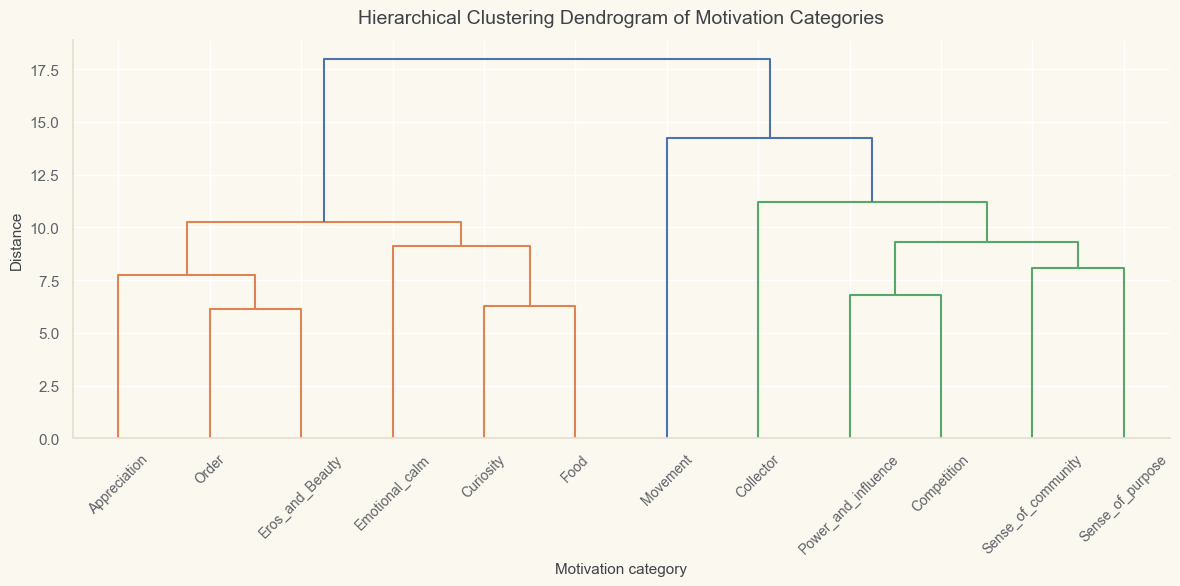

In [36]:
category_linkage_matrix = linkage(X_categories_scaled,
                                  method="ward"
                                 )

fig, ax = plt.subplots(figsize = (12, 6))

dendrogram(category_linkage_matrix,
           labels = X_categories_scaled.index.tolist(),
           leaf_rotation = 45,
           leaf_font_size = 10,
           color_threshold = None,
           ax=ax
          )

ax.set_title("Hierarchical Clustering Dendrogram of Motivation Categories", pad = 12)
ax.set_xlabel("Motivation category")
ax.set_ylabel("Distance")

sns.despine(ax = ax,
            left = False,
            bottom = False)

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Motivation Category Dendrogram Interpretation**

The dendrogram suggests that motivation categories do not behave independently. Several categories show similar response patterns across participants.

One broad group includes categories such as `Appreciation`, `Order`, `Eros_and_Beauty`, `Emotional_calm`, `Curiosity`, and `Food`. Within this group, `Curiosity` and `Food` are relatively close, suggesting that participants who score higher in one of these categories often show similar patterns in the other. `Appreciation`, `Order`, and `Eros_and_Beauty` also appear connected within the same broader branch.

A second broad group includes `Collector`, `Power_and_influence`, `Competition`, `Sense_of_community`, and `Sense_of_purpose`. This branch suggests another family of motivation categories with related response patterns.

`Movement` appears more separated than most other categories. It joins the right-side branch at a relatively high distance, suggesting that its response pattern is less similar to the other motivation categories.

Overall, the dendrogram supports the idea that motivation categories can be grouped into broader behavioral families, although the exact interpretation should remain exploratory because the dataset is small.
</div>


To make the dendrogram easier to summarize, I next assign each motivation category to one of two hierarchical clusters.

This does not mean that the two-cluster solution is the only possible interpretation. Rather, it provides a simple summary of the two broad branches visible in the dendrogram, while keeping in mind that `Movement` appears more separated from the rest of its branch.


In [37]:
category_cluster_model = AgglomerativeClustering(n_clusters = 2,
                                                 linkage = "ward"
                                                )

category_cluster_labels = category_cluster_model.fit_predict(X_categories_scaled)

df_category_clusters = pd.DataFrame({"Motivation category": X_categories_scaled.index,
                                     "Category_cluster": category_cluster_labels
                                    }
                                   )

display(df_category_clusters.sort_values("Category_cluster"))


,Motivation category,Category_cluster
0,Power_and_influence,0
1,Sense_of_community,0
4,Collector,0
5,Sense_of_purpose,0
7,Movement,0
11,Competition,0
2,Curiosity,1
3,Appreciation,1
6,Food,1
8,Emotional_calm,1


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Motivation Category Cluster Interpretation**

The two-cluster hierarchical solution groups the motivation categories into two broad families.

**Category Cluster 0** includes:

- `Power_and_influence`
- `Sense_of_community`
- `Collector`
- `Sense_of_purpose`
- `Movement`
- `Competition`

This group can be interpreted as a **social/drive-oriented motivation family**, because it includes categories related to influence, competition, community, purpose, collecting, and movement.

**Category Cluster 1** includes:

- `Curiosity`
- `Appreciation`
- `Food`
- `Emotional_calm`
- `Order`
- `Eros_and_Beauty`

This group can be interpreted as a **personal/reward-oriented motivation family**, because it includes categories related to curiosity, appreciation, sensory reward, calm, order, and beauty.

`Movement` should be interpreted carefully. Although it belongs to Category Cluster 0 in the two-cluster solution, the dendrogram shows that it joins the group at a relatively higher distance. This suggests that `Movement` may have a more distinct response pattern than the other categories in the same family.

Overall, this analysis supports the second project question: motivation categories can be grouped according to similar response patterns, but the grouping should be interpreted as exploratory rather than definitive.
</div>


To visualize the motivation-category families more clearly, I project the motivation categories into two dimensions using PCA.

_As before, PCA is used only for visualization. The category clusters were created using the full scaled category-pattern matrix, not only the two PCA components._


In [38]:
category_pca = PCA(n_components = 2,
                   random_state = 42)

category_pca_values = category_pca.fit_transform(X_categories_scaled)

df_category_pca = pd.DataFrame(category_pca_values,
                               columns=["PC1", "PC2"],
                               index=X_categories_scaled.index
                              )

df_category_pca = df_category_pca.reset_index().rename(columns = {"index": "Motivation category"})

df_category_pca = df_category_pca.merge(df_category_clusters,
                                        on = "Motivation category",
                                        how = "left"
                                       )

category_cluster_name_map = {0: "Social/drive-oriented",
                             1: "Personal/reward-oriented"
                            }

df_category_pca["Category family"] = (df_category_pca["Category_cluster"].map(category_cluster_name_map))

category_explained_variance = category_pca.explained_variance_ratio_

print("Explained variance by PC1:", round(category_explained_variance[0], 3))
print("Explained variance by PC2:", round(category_explained_variance[1], 3))
print("Total explained variance:", round(category_explained_variance.sum(), 3))

display(df_category_pca)


Explained variance by PC1: 0.431
Explained variance by PC2: 0.13
Total explained variance: 0.56


,Motivation category,PC1,PC2,Category_cluster,Category family
0,Power_and_influence,-1.662301,-3.452159,0,Social/drive-oriented
1,Sense_of_community,2.409940,-0.106972,0,Social/drive-oriented
2,Curiosity,-3.845094,0.091520,1,Personal/reward-oriented
3,Appreciation,-1.829894,0.661378,1,Personal/reward-oriented
4,Collector,3.667636,6.524690,0,Social/drive-oriented
5,Sense_of_purpose,3.739335,2.259625,0,Social/drive-oriented
6,Food,-4.689154,-0.616179,1,Personal/reward-oriented
7,Movement,10.053609,-3.177320,0,Social/drive-oriented
8,Emotional_calm,-8.063796,0.712607,1,Personal/reward-oriented
9,Order,-1.757003,0.145453,1,Personal/reward-oriented


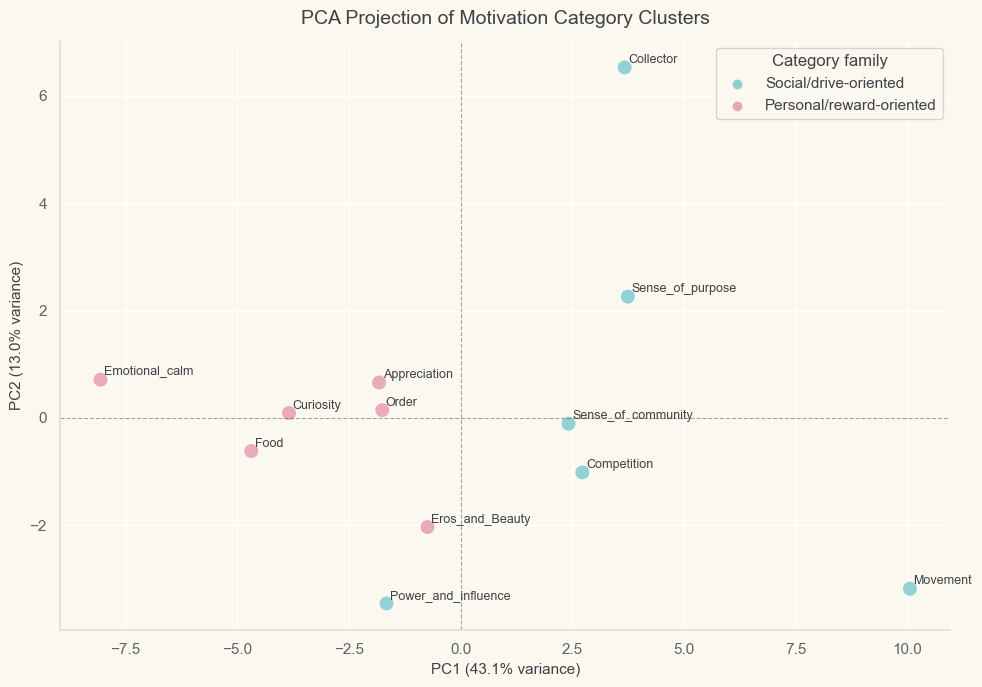

In [39]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(data = df_category_pca,
                x = "PC1",
                y = "PC2",
                hue = "Category family",
                palette = [PALETTE_MOTIVATION["teal"], PALETTE_MOTIVATION["pink"]],
                s = 120,
                edgecolor = "white",
                linewidth = 0.8,
                alpha = 0.95,
                ax = ax
               )

for _, row in df_category_pca.iterrows():
    ax.text(row["PC1"] + 0.08,
            row["PC2"] + 0.08,
            row["Motivation category"],
            fontsize = 9,
            color = PALETTE_MOTIVATION["dark_gray"]
        )

ax.axhline(0,
           color = PALETTE_MOTIVATION["gray"],
           linestyle = "--",
           linewidth = 0.8,
           alpha = 0.6
           )

ax.axvline(0,
           color = PALETTE_MOTIVATION["gray"],
           linestyle = "--",
           linewidth = 0.8,
           alpha = 0.6
           )

ax.set_title("PCA Projection of Motivation Category Clusters", pad = 12)
ax.set_xlabel(f"PC1 ({category_explained_variance[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({category_explained_variance[1] * 100:.1f}% variance)")
ax.legend(title="Category family")

sns.despine(ax = ax,
            left = False,
            bottom = False)

plt.tight_layout()
plt.show()


<div style="background-color:  #ebf2f2; padding: 10px;">

#### **Motivation Category PCA Interpretation**

The first two PCA components explain approximately 56.0% of the variation in the motivation-category response patterns. This means the 2D projection captures a meaningful part of the structure, but not the full relationship among categories.

The PCA plot supports the hierarchical clustering result: the personal/reward-oriented categories tend to appear on the left side of PC1, while several social/drive-oriented categories appear on the right side.

`Movement` is clearly separated from the other categories along PC1. This confirms the dendrogram observation that `Movement` has a more distinct response pattern and should be interpreted carefully within the social/drive-oriented family.

The plot also shows that the category families are exploratory rather than perfectly separated. Some categories, such as `Power_and_influence` and `Eros_and_Beauty`, appear closer to the center or opposite side of their broader family in the 2D projection. This can happen because PCA only shows part of the full high-dimensional structure.

Overall, the PCA visualization helps communicate the two broad motivation-category families while also showing that some categories have more nuanced positions.
</div>


<div style="background-color:  #e9edf1; padding: 10px;">

## **Answer to Project Question 2: Can Motivation Categories Be Grouped by Similar Response Patterns?**

**Yes**, the analysis suggests that motivation categories can be grouped according to similar response patterns across participants.

The hierarchical clustering analysis groups the 12 motivation categories into two broad response-pattern families.

The first family is a **social/drive-oriented** group, containing `Power_and_influence`, `Sense_of_community`, `Collector`, `Sense_of_purpose`, `Movement`, and `Competition`.

The second family is a **personal/reward-oriented** group, containing `Curiosity`, `Appreciation`, `Food`, `Emotional_calm`, `Order`, and `Eros_and_Beauty`.

The dendrogram and PCA visualization both suggest that `Movement` behaves more distinctly than the other categories in its assigned family. Therefore, it should be interpreted as part of the broad social/drive-oriented group, but with a less typical response pattern.

Overall, the category-level analysis shows that motivation categories do not behave independently. They form interpretable families of related response patterns. However, because the dataset is small, these groups should be understood as exploratory patterns rather than definitive psychological categories.


</div>

<div style="color:white; background-color:#b2cdcd; padding:10px;">

## **Project Conclusions and Limitations**

</div>

This project used unsupervised learning to explore motivation profiles across participants and relationships among motivation categories.

The participant-level analysis suggests that the dataset contains one broad main group, a smaller lower drive/exploration profile, and a few especially unusual participants. K-Means, hierarchical clustering, and DBSCAN did not produce identical results, but they agreed on an important point: a small subset of participants shows motivation patterns that differ from the majority.

The category-level analysis suggests that motivation categories can be grouped into two broad response-pattern families: a social/drive-oriented family and a personal/reward-oriented family. `Movement` appears more distinct than the other categories and should be interpreted carefully within its assigned family.

_The most important methodological conclusion is that the clustering structure is exploratory and gradual rather than sharply separated._ DBSCAN did not identify multiple dense clusters, which suggests that the data may not contain strongly separated natural groups. Instead, the results point to soft differences in motivation profiles.


### **Limitations**

The dataset contains only 49 participants, so the results should not be generalized without further validation on a larger sample.

Cluster names were assigned after profiling the clusters and should be interpreted as descriptive labels, not as fixed psychological categories.

The analysis is based on numerical motivation scores only. Additional demographic, behavioral, or contextual information could help validate whether the identified profiles are meaningful in practice.

Because this is an unsupervised learning project, there is no external target variable to confirm the “correct” clustering solution. The conclusions are based on consistency across methods, interpretability, and exploratory structure.